In [1]:
# Parameters
system_name = "J2325-5229"
filter = "F160W"
use_psf_variance_map = True
r1 = 3.1
dx_outer = 0.1
dy_outer = 0.35
dx_center = 0.1
dy_center = 0.1
x1 = 40
y1 = 65
x2 = 46
y2 = 44
x3 = 58
y3 = 34
use_center_mask = False
r1_f814w = 2.2
dx_outer_f814w = 0.0
dy_outer_f814w = 0.2
lens_center_x_f814w = 95
lens_center_y_f814w = 87
r1_f475x = 2.2
dx_outer_f475x = 0.0
dy_outer_f475x = 0.2
lens_center_x_f475x = 95
lens_center_y_f475x = 87


In [2]:
# Standard Python imports
import os
import copy
import h5py
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Astropy imports
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization import ImageNormalize, LogStretch
import astropy.io.fits as pyfits

# Lenstronomy imports
import lenstronomy
from lenstronomy.Plots import chain_plot
from lenstronomy.Plots.model_plot import ModelPlot
from lenstronomy.Data.psf import PSF
from lenstronomy.Util import kernel_util
from lenstronomy.Data.pixel_grid import PixelGrid
from lenstronomy.Workflow.fitting_sequence import FittingSequence
from lenstronomy.Util import mask_util, util

import pickle

In [3]:
def plot_band(modelPlot, band_index_plot):
    """
    a set of plotting routines for a ModelPlot() instance with specified band
    """

    f, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=False, sharey=False)

    modelPlot.data_plot(ax=axes[0,0], band_index=band_index_plot)
    modelPlot.model_plot(ax=axes[0,1], band_index=band_index_plot)
    modelPlot.normalized_residual_plot(ax=axes[0,2], v_min=-6, v_max=6, band_index=band_index_plot)
    modelPlot.source_plot(ax=axes[1, 0], deltaPix_source=0.01, numPix=100,  v_min=-6, v_max=0, band_index=band_index_plot)
    modelPlot.convergence_plot(ax=axes[1, 1], v_max=1, band_index=band_index_plot)
    modelPlot.magnification_plot(ax=axes[1, 2], band_index=band_index_plot)
    f.tight_layout()
    f.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0., hspace=0.05)
    plt.show()

    f, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=False, sharey=False)

    modelPlot.decomposition_plot(ax=axes[0,0], band_index=band_index_plot, text='Lens light', lens_light_add=True, unconvolved=True)
    modelPlot.decomposition_plot(ax=axes[1,0], band_index=band_index_plot, text='Lens light convolved', lens_light_add=True)
    modelPlot.decomposition_plot(ax=axes[0,1], band_index=band_index_plot, text='Source light', source_add=True, unconvolved=True)
    modelPlot.decomposition_plot(ax=axes[1,1], band_index=band_index_plot, text='Source light convolved', source_add=True)
    modelPlot.decomposition_plot(ax=axes[0,2], band_index=band_index_plot, text='All components', source_add=True, lens_light_add=True, unconvolved=True)
    modelPlot.decomposition_plot(ax=axes[1,2], band_index=band_index_plot, text='All components convolved', source_add=True, lens_light_add=True, point_source_add=True)
    f.tight_layout()
    f.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0., hspace=0.05)
    plt.show()

import sys
import os
import contextlib

@contextlib.contextmanager
def suppress_stdout_stderr(to_file):
    """
    Redirect stdout and stderr to a file.
    """
    with open(to_file, 'w') as f:
        old_stdout = sys.stdout
        old_stderr = sys.stderr
        sys.stdout = f
        sys.stderr = f
        try:
            yield
        finally:
            sys.stdout = old_stdout
            sys.stderr = old_stderr

In [4]:
filename = f"joint_modeling/{system_name}/{system_name}_joint.pkl"

# load the saved data and plot the models
with open(filename, "rb") as f:
    loaded_data = pickle.load(f)

kwargs_result = loaded_data["kwargs_result"]
multi_band_list = loaded_data["multi_band_list"]
kwargs_model = loaded_data["kwargs_model"]
kwargs_params = loaded_data.get("kwargs_params", None)
chain_list = loaded_data.get('chain_list')
kwargs_constraints = loaded_data.get("kwargs_constraints", None)
kwargs_likelihood = loaded_data.get("kwargs_likelihood", None)
kwargs_data_joint = loaded_data.get("kwargs_data_joint", None)

In [5]:
source_model_list = ['SERSIC_ELLIPSE', 'SHAPELETS']
index_source_light_model_list = [[0, 1], [0], [0]]

kwargs_model.update({'source_light_model_list': source_model_list})
kwargs_model.update({'index_source_light_model_list': index_source_light_model_list})
kwargs_constraints.update({
    'joint_source_with_source': [[0, 1, ['center_x', 'center_y']]]
})

kwargs_source_init = kwargs_result['kwargs_source']
kwargs_source_init.extend([{'beta': 0.2, 'center_x': 0., 'center_y': 0.}])

kwargs_source_sigma = kwargs_params['source_model'][1]
kwargs_source_sigma.extend([{'beta': 0.1, 'center_x': .3, 'center_y': 0.3}])

kwargs_lower_source = kwargs_params['source_model'][3]
kwargs_lower_source.extend([{'beta': 0.01, 'center_x': -10, 'center_y': -10}])

kwargs_upper_source = kwargs_params['source_model'][4]
kwargs_upper_source.extend([{'beta': 100, 'center_x': 10, 'center_y': 10}])

lens_params = [kwargs_result['kwargs_lens'], kwargs_params['lens_model'][1], [{'gamma': 2}, {'ra_0': 0, 'dec_0': 0}], kwargs_params['lens_model'][3], kwargs_params['lens_model'][4]]
lens_light_params = [kwargs_result['kwargs_lens_light'], kwargs_params['lens_light_model'][1], [{}, {}, {}, {}], kwargs_params['lens_light_model'][3], kwargs_params['lens_light_model'][4]]
source_params = [kwargs_source_init, kwargs_source_sigma, [{}, {'n_max': 5}], kwargs_lower_source, kwargs_upper_source]
ps_params = [kwargs_result['kwargs_ps'], kwargs_params['point_source_model'][1], [{}], kwargs_params['point_source_model'][3], kwargs_params['point_source_model'][4]]

kwargs_params = {'lens_model': lens_params,
                 'source_model': source_params,
                'lens_light_model': lens_light_params,
                'point_source_model': ps_params}

fitting_seq = FittingSequence(kwargs_data_joint, kwargs_model, kwargs_constraints, kwargs_likelihood, kwargs_params, verbose = False)


/gpfs/home/rmbrady/miniconda3/envs/doubles/lib/python3.12/site-packages/lenstronomy/Data/psf.py:95: UserWarning: Input PSF model has at least one negative element, which is unphysical except for a PSF of an interferometric array.
  warnings.warn(


iteration of step 0 gave best reconstruction.
log likelihood before: -5918.753789286557 and log likelihood after: -5918.753789286557


iteration of step 8 gave best reconstruction.
log likelihood before: -5992.197498330441 and log likelihood after: -5982.789903531675


iteration of step 29 gave best reconstruction.
log likelihood before: -4303.214610707854 and log likelihood after: -4300.806745840244


iteration of step 0 gave best reconstruction.
log likelihood before: -5879.299358353752 and log likelihood after: -5879.299358353752


...

100%|██████████| 1500/1500 [10:34:46<00:00, 25.39s/it]


/gpfs/home/rmbrady/miniconda3/envs/doubles/lib/python3.12/site-packages/lenstronomy/Plots/model_band_plot.py:68: RuntimeWarning: divide by zero encountered in log10
  log_model = np.log10(model)
/gpfs/home/rmbrady/miniconda3/envs/doubles/lib/python3.12/site-packages/lenstronomy/Plots/model_band_plot.py:68: RuntimeWarning: invalid value encountered in log10
  log_model = np.log10(model)


Computing the MCMC...
Number of walkers =  360
Burn-in iterations:  500
Sampling iterations (in current run): 1500
38113.398566007614 time taken for MCMC sampling
-1.3508229038984312 reduced X^2 of all evaluated imaging data combined (without degrees of freedom subtracted).
reduced chi^2 of data  0 =  2.4293505292562076
reduced chi^2 of data  1 =  1.2573922855139779
reduced chi^2 of data  2 =  0.9071995099286481


/gpfs/home/rmbrady/miniconda3/envs/doubles/lib/python3.12/site-packages/lenstronomy/Plots/model_band_plot.py:161: RuntimeWarning: invalid value encountered in log10
  np.log10(self._data),
/gpfs/home/rmbrady/miniconda3/envs/doubles/lib/python3.12/site-packages/lenstronomy/Plots/model_band_plot.py:225: RuntimeWarning: divide by zero encountered in log10
  np.log10(self._model),


/tmp/ipykernel_1542514/2448189218.py:14: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  f.tight_layout()


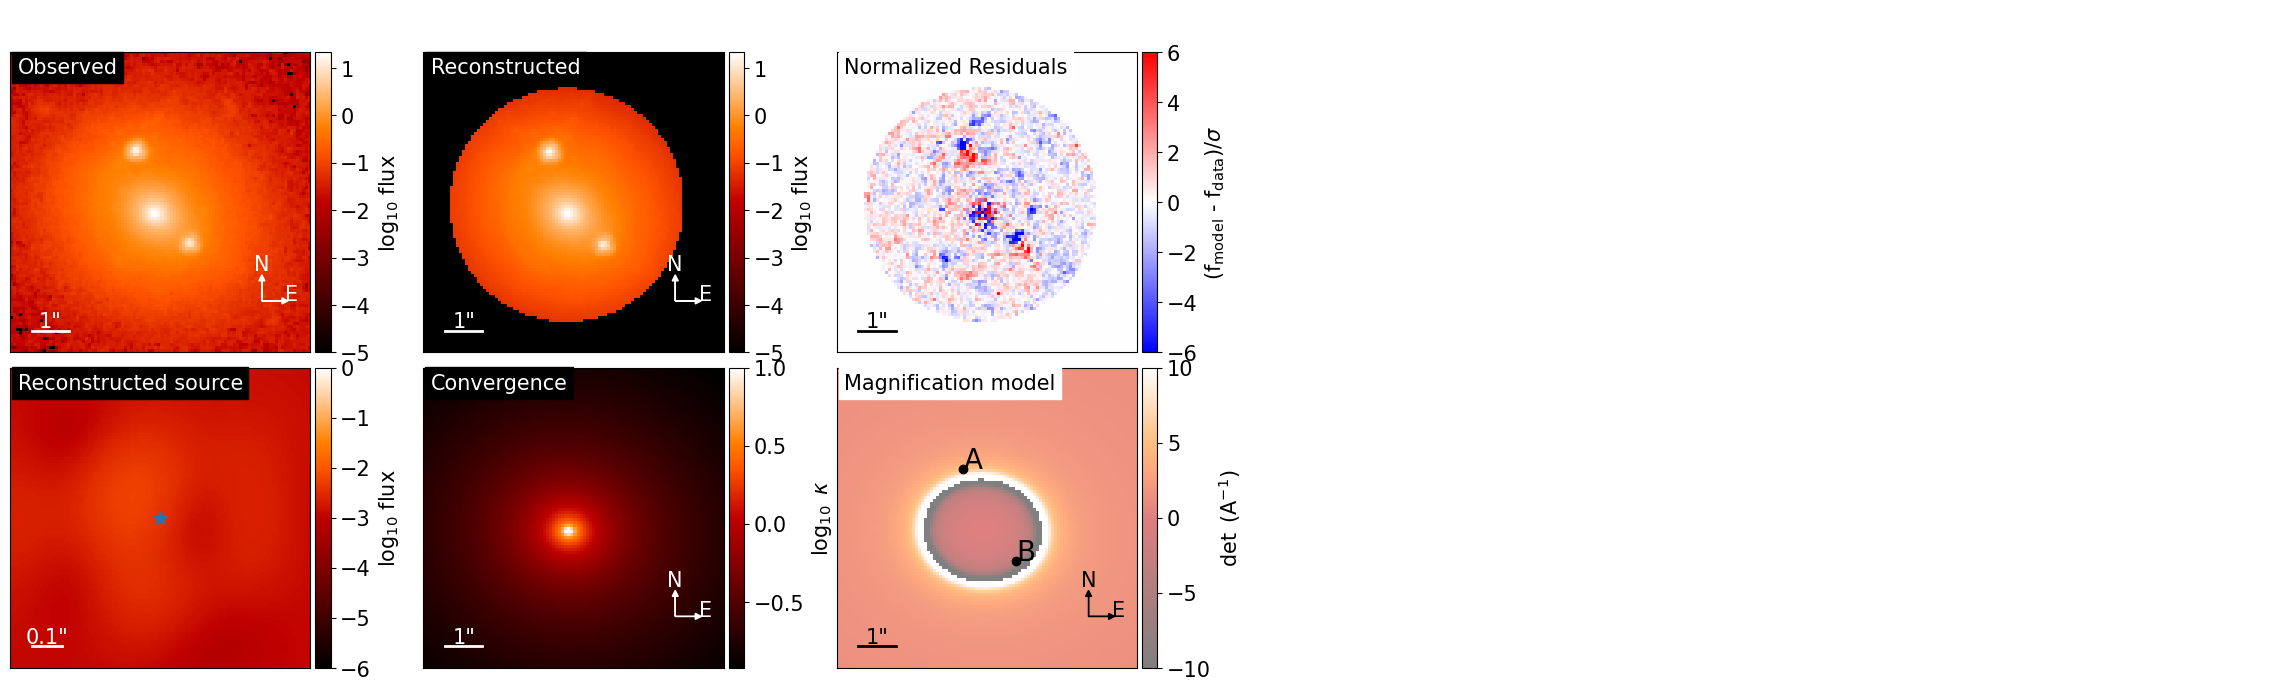

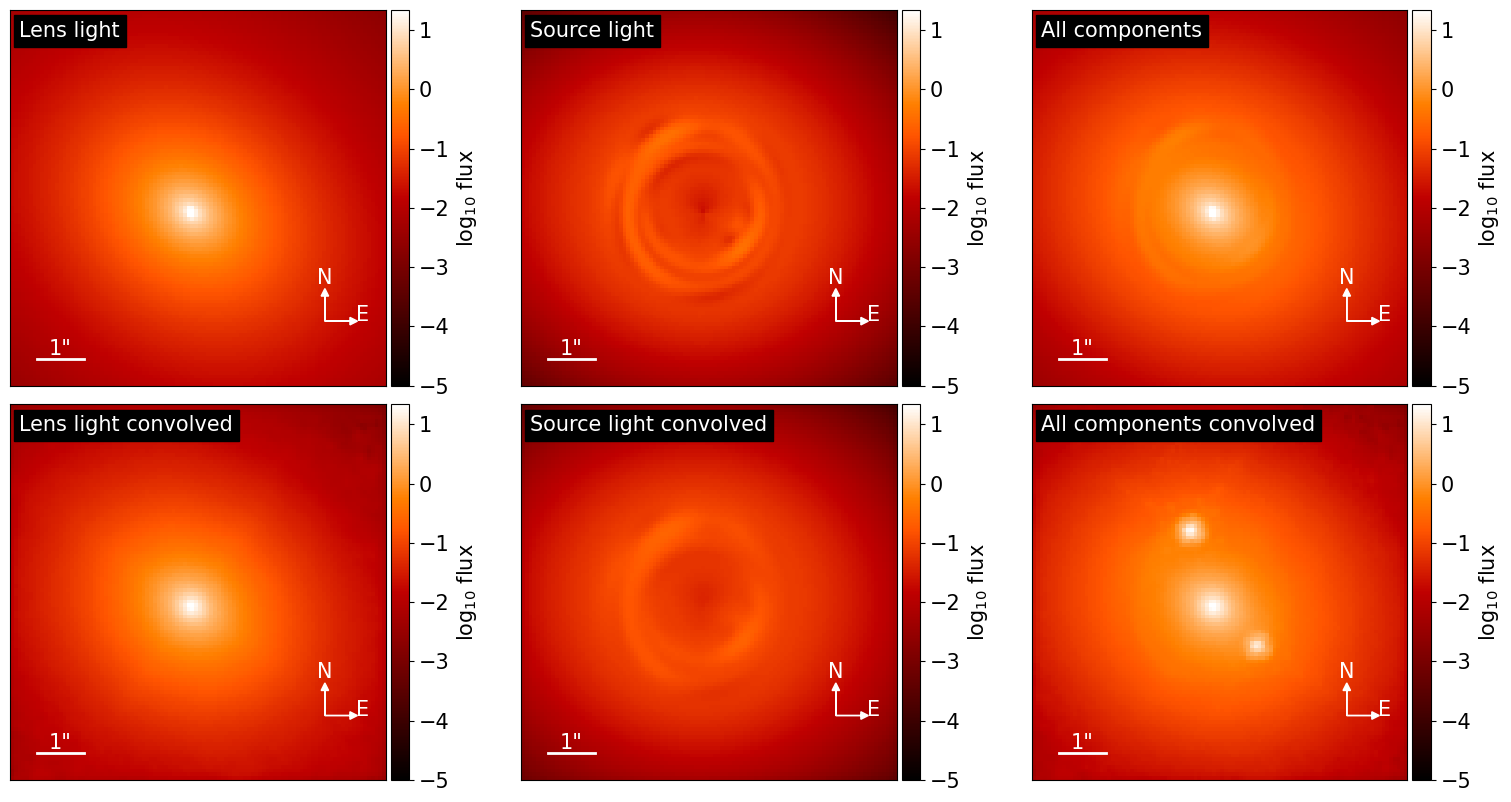

########################################################


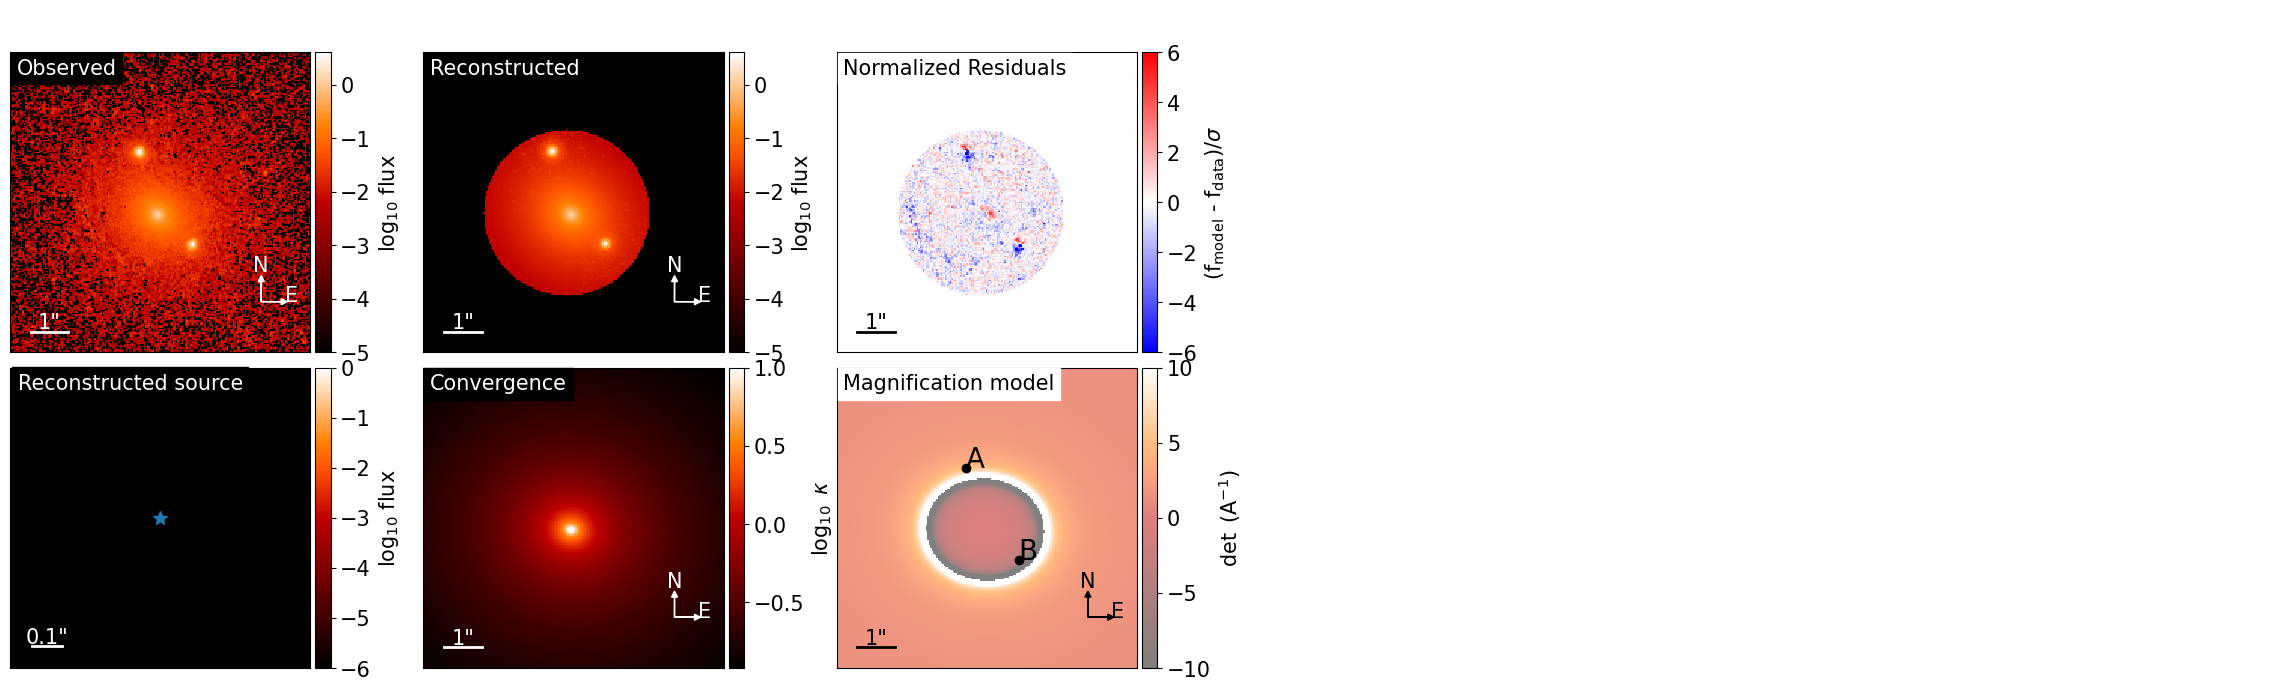

/gpfs/home/rmbrady/miniconda3/envs/doubles/lib/python3.12/site-packages/lenstronomy/Plots/model_band_plot.py:1121: RuntimeWarning: invalid value encountered in log10
  np.log10(model),


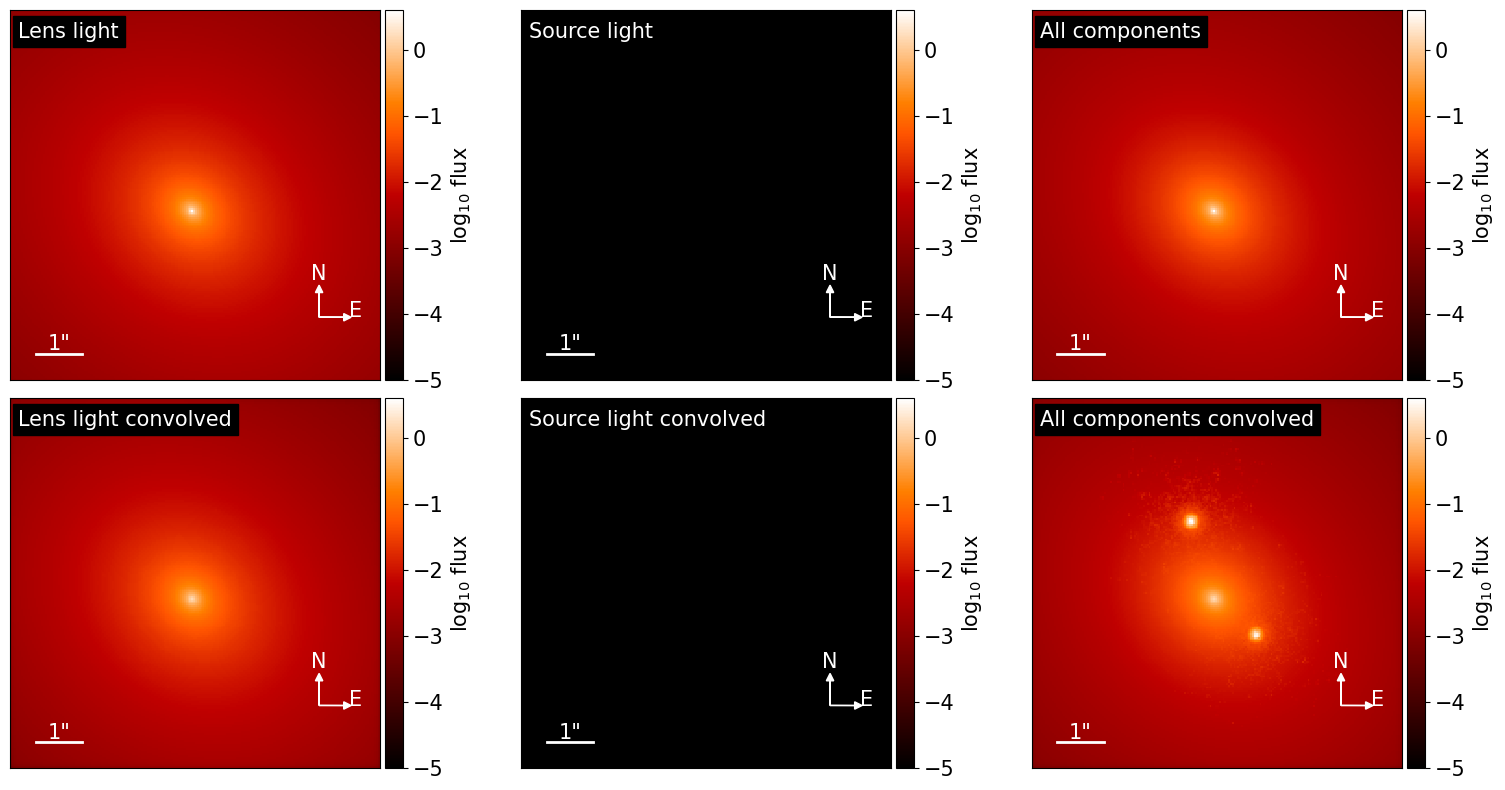

########################################################


/gpfs/home/rmbrady/miniconda3/envs/doubles/lib/python3.12/site-packages/lenstronomy/Plots/model_band_plot.py:225: RuntimeWarning: invalid value encountered in log10
  np.log10(self._model),


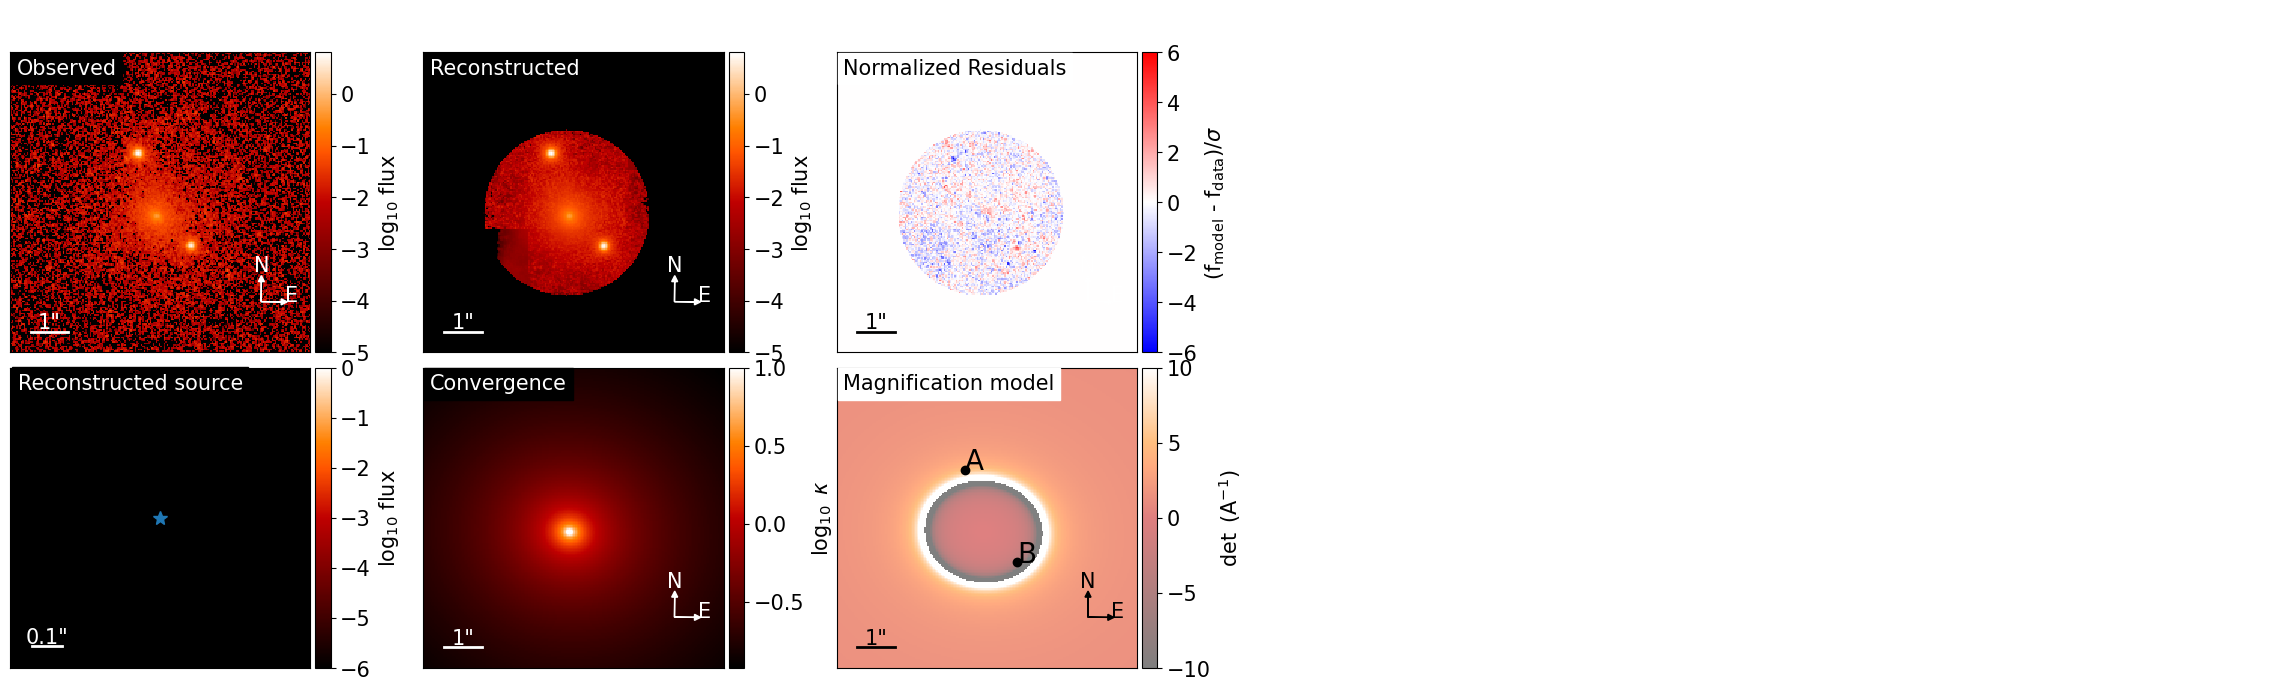

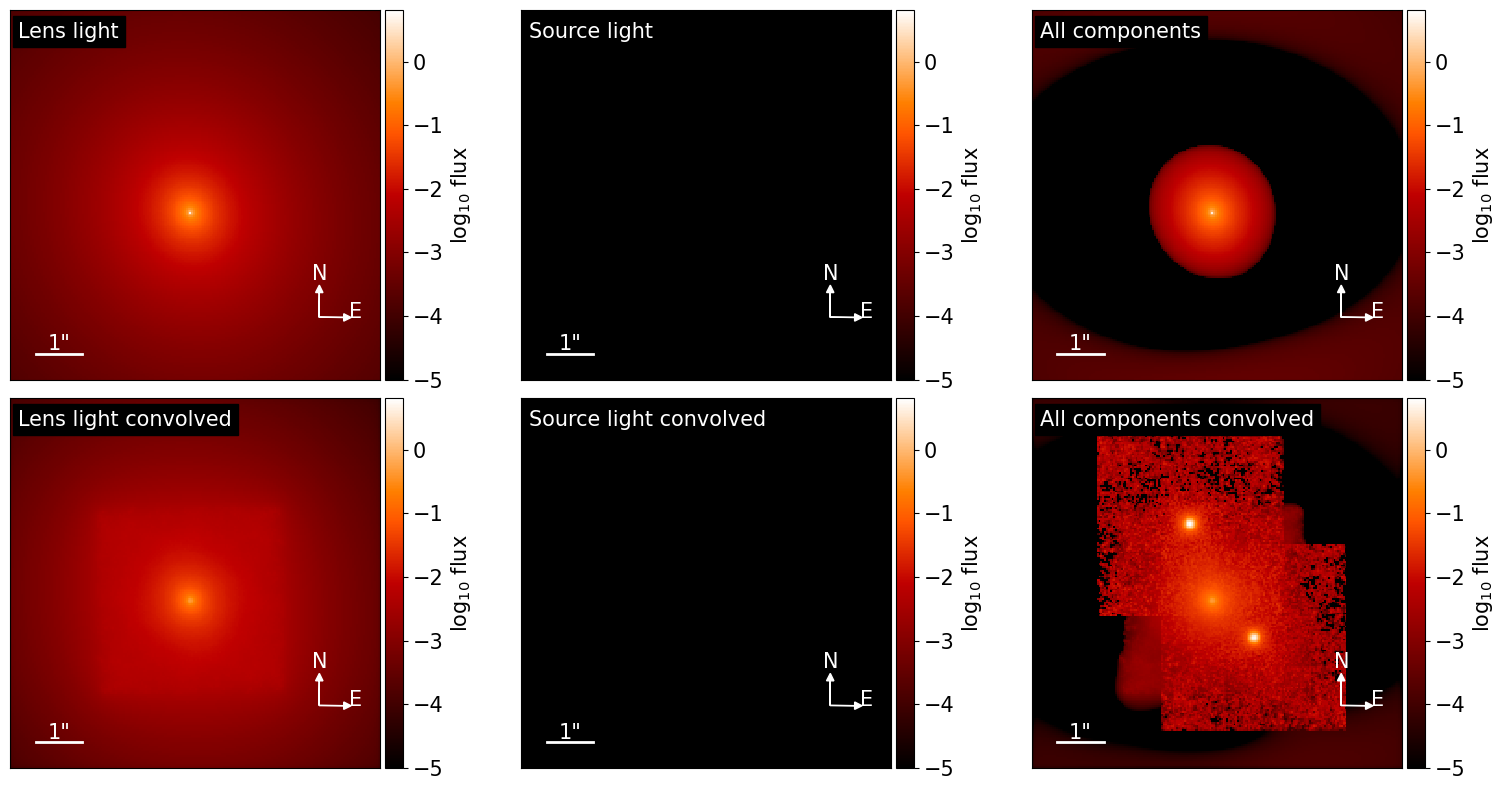

In [6]:
# run a final round of optimization + posterior sampling

kwargs_psf_iter = {'stacking_method': 'median', 
                    'psf_symmetry': 4, 
                    'block_center_neighbour': 0.05,
                    'num_iter': 500, 
                    'psf_iter_factor': 0.2,
                    'compute_bands': [True, True, True]
                      }

if use_psf_variance_map ==  True:
    kwargs_psf_iter.update({'keep_psf_variance_map': True})

fitting_kwargs_list = [
                       ['PSO', {'sigma_scale': 1., 'n_particles': 100, 'n_iterations': 100}],
                       ['psf_iteration', kwargs_psf_iter],
                       ['PSO', {'sigma_scale': 1., 'n_particles': 100, 'n_iterations': 100}],
                       ['psf_iteration', kwargs_psf_iter],
                       ['PSO', {'sigma_scale': 1., 'n_particles': 200, 'n_iterations': 250}],
                       ['MCMC', {'n_burn': 500, 'n_run': 1000, 'walkerRatio': 10,'sigma_scale': .1}]

]

chain_list = fitting_seq.fit_sequence(fitting_kwargs_list)
kwargs_result = fitting_seq.best_fit()
multi_band_list_out = fitting_seq.multi_band_list

modelPlot = ModelPlot(multi_band_list_out, kwargs_model, kwargs_result, image_likelihood_mask_list=kwargs_likelihood["image_likelihood_mask_list"], arrow_size=0.02, cmap_string="gist_heat")
    
plot_band(modelPlot, band_index_plot=0)
print('########################################################')
plot_band(modelPlot, band_index_plot=1)
print('########################################################')
plot_band(modelPlot, band_index_plot=2)

In [7]:
# save the class data for later analysis

save_dict = {
    "fitting_seq": fitting_seq,
    "kwargs_result": kwargs_result,
    "multi_band_list": multi_band_list,
    "kwargs_model": kwargs_model,
    "kwargs_params": kwargs_params,
    "chain_list": chain_list,
    "kwargs_constraints": kwargs_constraints,
    "kwargs_likelihood": kwargs_likelihood,
    "kwargs_data_joint": kwargs_data_joint
}

with open(f"joint_modeling/{system_name}/{system_name}_joint.pkl", "wb") as f:
    pickle.dump(save_dict, f)
